# UAS Data Mining — Prediksi PM2.5 & Segmentasi Kualitas Udara

**Nama:** RAFIKHAR LUCIANO  
**Metode:** Regresi (prediksi PM2.5) + Clustering (K-Means)  
**Framework:** CRISP-DM  
**Dataset:** UCI Beijing PM2.5 Data Set


## 1. Business Understanding

Polusi udara (PM2.5) berdampak pada kesehatan. Tujuan proyek:
1. Memprediksi nilai PM2.5 dari faktor cuaca (regresi).
2. Mengelompokkan kondisi udara (clustering K-Means).

Kriteria sukses: R2 tinggi & RMSE rendah untuk regresi; Silhouette baik untuk clustering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, silhouette_score)
import joblib, os

## 2. Data Understanding

In [3]:
DATA_PATH = 'PRSA_data_2010.1.1-2014.12.31.csv'
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(43824, 13)


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [5]:
df.describe()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,21912.500000,2012.000000,6.523549,15.727820,11.500000,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,12651.043435,1.413842,3.448572,8.799425,6.922266,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,1.000000,2010.000000,1.000000,1.000000,0.000000,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,10956.750000,2011.000000,4.000000,8.000000,5.750000,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,21912.500000,2012.000000,7.000000,16.000000,11.500000,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,32868.250000,2013.000000,10.000000,23.000000,17.250000,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,43824.000000,2014.000000,12.000000,31.000000,23.000000,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


# Deskripsi Fitur Dataset

1. No: nomor baris
2. year: tahun data pada baris
3. month: bulan data pada baris
4. day: hari data pada baris
5. hour: jam data pada baris
6. pm2.5: konsentrasi PM2.5 (ug/m^3)
7. DEWP: Dew Point / Titik Embun (℃)
8. TEMP: Suhu (℃)
9. PRES: Tekanan (hPa)
10. cbwd: Arah angin gabungan
11. Iws: Kecepatan angin kumulatif (m/s)
12. Is: Jam salju kumulatif
13. Ir: Jam hujan kumulatif









# Cek Missing Value


In [6]:
# Cek missing value
df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
pm2.5,2067
DEWP,0
TEMP,0
PRES,0
cbwd,0


Hasil menunjukkan terdapat nilai kosong / missing value pada fitur pm2.5 sebanyak 2067.

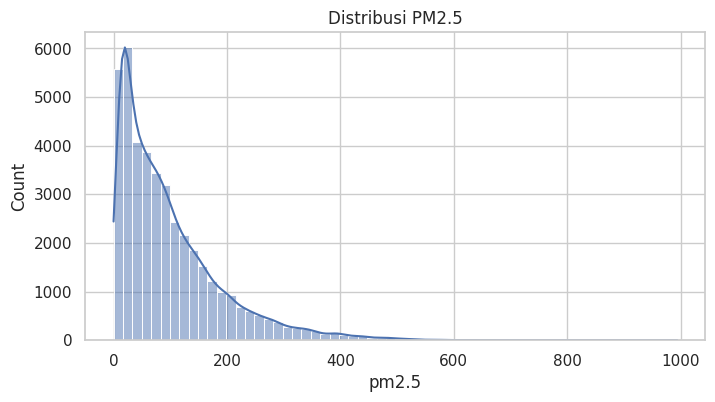

In [7]:
# Distribusi target PM2.5
plt.figure(figsize=(8,4))
sns.histplot(df['pm2.5'].dropna(), bins=60, kde=True)
plt.title('Distribusi PM2.5')
plt.show()

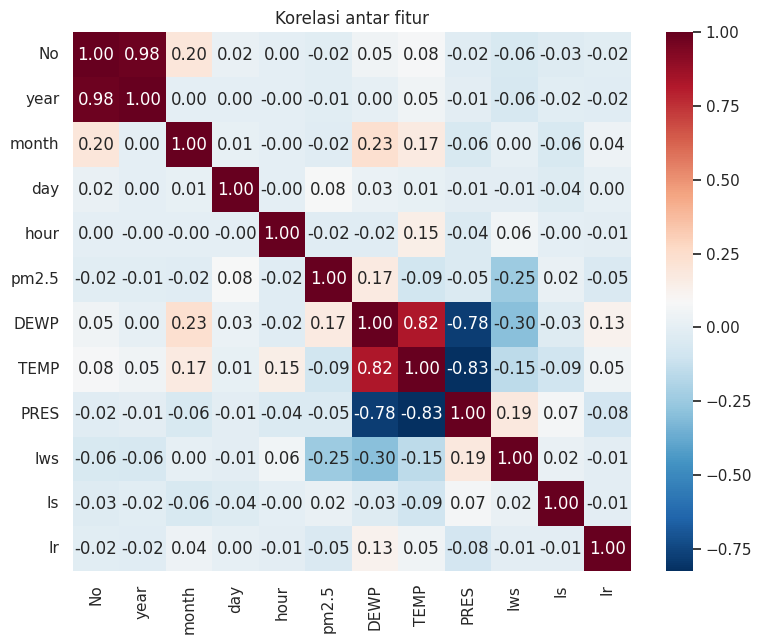

In [8]:
# Heatmap korelasi
plt.figure(figsize=(9,7))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='RdBu_r')
plt.title('Korelasi antar fitur')
plt.show()

## 3. Data Preparation

In [9]:
df = df.copy()
if 'No' in df.columns:
    df = df.drop(columns=['No'])
# Buang baris tanpa target, isi sisa missing dengan median/modus
df = df.dropna(subset=['pm2.5']).reset_index(drop=True)

NUMERIC = ['month','hour','DEWP','TEMP','PRES','Iws','Is','Ir']
CATEG = ['cbwd']
for c in NUMERIC:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    df[c] = df[c].fillna(df[c].median())
df['cbwd'] = df['cbwd'].fillna(df['cbwd'].mode().iloc[0])
print(df.shape)

(41757, 12)


## 4. Modeling

### 4A. Regresi — Prediksi PM2.5

In [10]:
X = df[NUMERIC + CATEG]
y = df['pm2.5']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

prep = ColumnTransformer([
    ('num', 'passthrough', NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEG),
])

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=12, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=120, max_depth=18, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}
results = {}
best_name, best_pipe, best_r2 = None, None, -1e9
for name, est in models.items():
    pipe = Pipeline([('prep', prep), ('model', est)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    if r2 > best_r2:
        best_name, best_pipe, best_r2 = name, pipe, r2
pd.DataFrame(results).T

,MAE,RMSE,R2
Linear Regression,57.223869,80.598158,0.262776
Decision Tree,42.558398,66.663129,0.495663
Random Forest,35.460108,55.302631,0.652911
Gradient Boosting,46.927116,68.199124,0.472154


Hasil evaluasi model menunjukkan random forest memiliki nilai MAE / RMSE terendah (semakindan rendah semakin baik) dan R2 tertinggi (semakin tinggi semakin baik), sehingga model tersebut dipilih menjadi model terbaik.

In [11]:
print('Model terbaik:', best_name)

Model terbaik: Random Forest


# Prediksi vs Aktual untuk model terbaik

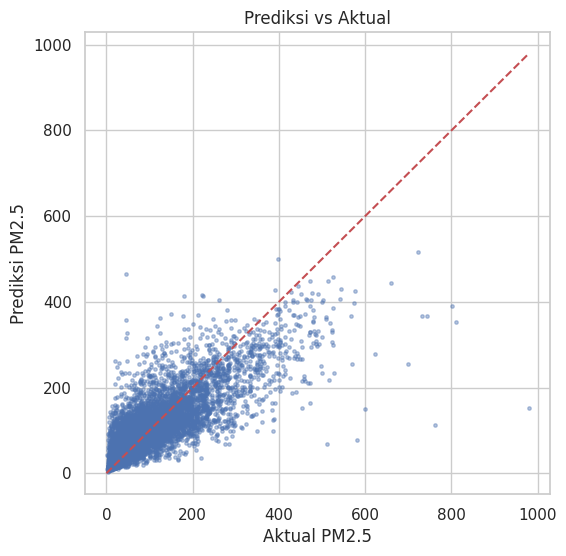

In [16]:

pred = best_pipe.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, s=6, alpha=0.4)
lims = [0, max(y_test.max(), pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Aktual PM2.5'); plt.ylabel('Prediksi PM2.5'); plt.title('Prediksi vs Aktual'); plt.show()

### 4B. Clustering — K-Means

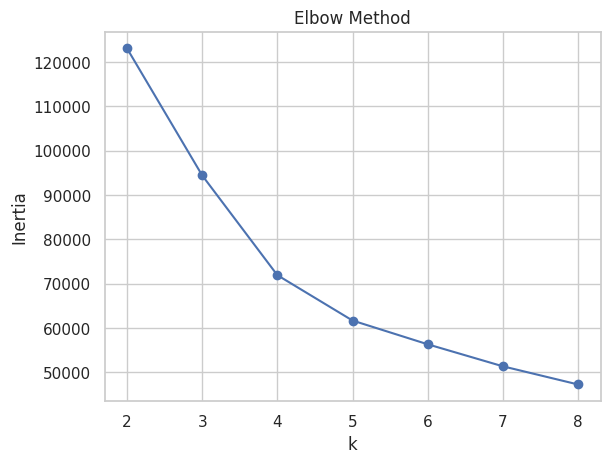

In [12]:
CLUSTER_FEATURES = ['TEMP','DEWP','PRES','Iws','pm2.5']
cdf = df[CLUSTER_FEATURES].dropna()
scaler = StandardScaler().fit(cdf)
scaled = scaler.transform(cdf)

# Elbow method
inertia = []
K = range(2, 9)
for k in K:
    inertia.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled).inertia_)
plt.plot(list(K), inertia, 'o-'); plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method'); plt.show()

Hasil Elbow Method menunjukkan nilai k optimal berada pada k = 4, sehingga dipilih jumlah kluster sebanyak 4

In [13]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(scaled)
sil = silhouette_score(scaled, labels)
print('Silhouette Score:', round(sil, 3))

Silhouette Score: 0.412


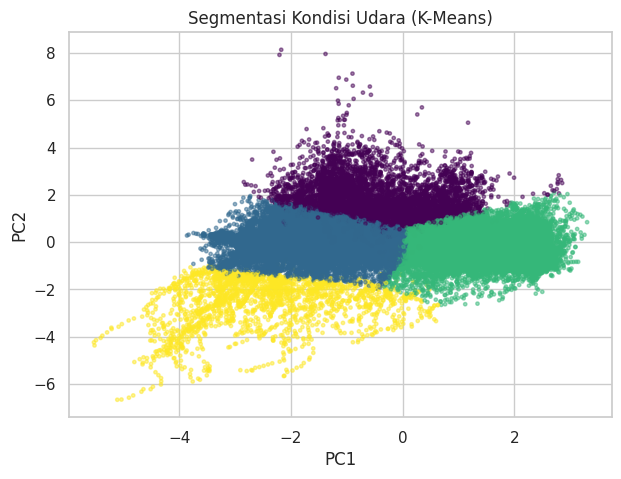

In [14]:
pca = PCA(n_components=2).fit_transform(scaled)
plt.figure(figsize=(7,5))
plt.scatter(pca[:,0], pca[:,1], c=labels, cmap='viridis', s=6, alpha=0.5)
plt.title('Segmentasi Kondisi Udara (K-Means)'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.show()

In [20]:
tmp = cdf.assign(cluster=labels)

cluster_summary = tmp.groupby('cluster')[CLUSTER_FEATURES].mean().round(2)
cluster_summary['jumlah_data'] = tmp.groupby('cluster').size()

cluster_summary = cluster_summary.sort_index()

print(cluster_summary.to_string())


          TEMP   DEWP     PRES     Iws   pm2.5  jumlah_data
cluster                                                    
0         4.64  -0.67  1019.86    6.07  275.01         5410
1         2.40 -11.22  1025.26   17.72   60.30        14662
2        23.06  14.02  1007.95   14.15   86.94        19571
3         3.00 -15.68  1025.19  202.02   21.00         2114


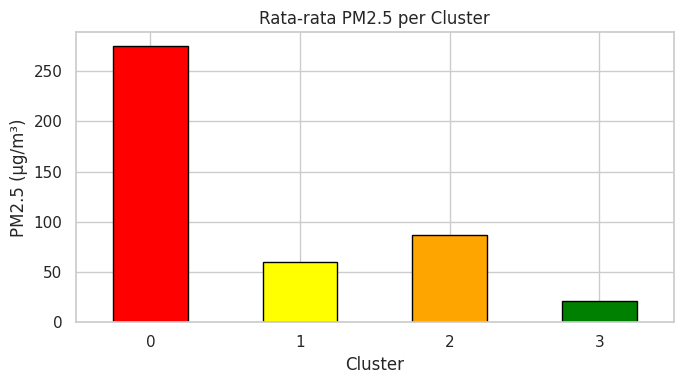

In [23]:
plt.figure(figsize=(7, 4))
cluster_summary['pm2.5'].plot(kind='bar', color=['red','yellow','orange','green'], edgecolor='black')
plt.title('Rata-rata PM2.5 per Cluster')
plt.xlabel('Cluster')
plt.ylabel('PM2.5 (µg/m³)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Interpretasi

Berdasarkan hasil klustering menunjukkan terdapat 4 kluster, dimana:

Kluster 0: Merupakan kluster dengan kadar PM2.5 tertinggi, yang mengindikasikan udara dengan polusi tinggi.

Kluster 1: Kluster ini memiliki kadar PM2.5 tidak terlalu tinggi, yang menunjukkan bahwa kualitas udara pada kluster ini memiliki polusi sedang/tidak terlalu tinggi

Kluster 2: Kadar PM2.5 pada kluster ini menjadi urutan kedua setelah kluster 0, yang mengindikasikan kualitas udara pada kluster ini cukup buruk.

Kluster 3: Pada kluster ini kadar PM2.5 terendah diantara kluster lain, yang menjadikan kualitas udara pada kluster ini paling sehat / bebas polusi

## 5. Evaluation

- Regresi dibandingkan dengan MAE, RMSE, R2 (lihat tabel di atas).
- Clustering dievaluasi dengan Silhouette Score & interpretasi tiap cluster.

## 6. Deployment — Simpan Artefak

In [17]:
os.makedirs('../model', exist_ok=True)
joblib.dump(best_pipe, '../model/model.pkl')
joblib.dump(kmeans, '../model/kmeans.pkl')
joblib.dump(scaler, '../model/scaler.pkl')
meta = {
    'reg_features': NUMERIC + CATEG,
    'numeric_features': NUMERIC,
    'categorical_features': CATEG,
    'cluster_features': CLUSTER_FEATURES,
    'target': 'pm2.5',
    'cbwd_categories': sorted(df['cbwd'].unique().tolist()),
    'best_model': best_name,
    'reg_results': results,
    'cluster_labels': label_map,
    'silhouette': float(sil),
    'feature_ranges': {c: [float(df[c].min()), float(df[c].max())] for c in NUMERIC},
    'feature_medians': {c: float(df[c].median()) for c in NUMERIC},
}
joblib.dump(meta, '../model/meta.pkl')
print('Artefak tersimpan di folder model/. Model siap dipakai aplikasi Streamlit.')

Artefak tersimpan di folder model/. Model siap dipakai aplikasi Streamlit.
